# WR MLP Comparison: Feature Reduction + Regularization Improvements

Three models compared:

| Model | Features | Architecture | Regularization |
|---|---|---|---|
| A) Original MLP | 184 | 5 layers, Optuna best from Career_RNN_Optuna | Original sample weights |
| B) Reduced MLP | 40 | Same architecture as A | Same sample weights |
| C) Improved MLP | 40 | Optuna (constrained), GaussianNoise, Mixup | Softened weights, forced LayerNorm |

Goal: isolate the effect of feature reduction (A vs B) and then improvements (B vs C).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import os, json, gc, time, random

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, losses, Model, Input
from tensorflow.keras.layers import (
    Dense, Dropout, LayerNormalization, GaussianNoise, BatchNormalization
)

import optuna
from optuna_integration.tfkeras import TFKerasPruningCallback
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['figure.figsize'] = (14, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

print(f'TensorFlow {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow 2.21.0
GPU available: False


---
## 1. Data Pipeline (identical to WR_Career_RNN_Optuna.ipynb)

In [2]:
df = pd.read_csv('../data/fully combined/wr_all_weeks.csv')
df['week'] = df['game_id'].str.split('_').str[1].astype(int)
df = df.sort_values(['receiver_player_id', 'season', 'week']).reset_index(drop=True)
print(f'Shape: {df.shape}')

Shape: (46115, 100)


In [3]:
work_df = df.copy()

# --- Rename WP columns ---
wp_rename_map = {
    'yards_wp_<25': 'yards_wp_less_than_25',
    'yards_wp_>75': 'yards_wp_greater_than_75',
    'receptions_wp_<25': 'receptions_wp_less_than_25',
    'receptions_wp_>75': 'receptions_wp_greater_than_75',
    'targets_wp_<25': 'targets_wp_less_than_25',
    'targets_wp_>75': 'targets_wp_greater_than_75',
}
work_df = work_df.rename(columns={k: v for k, v in wp_rename_map.items() if k in work_df.columns})

# --- Infer player team and detect changes ---
work_df['player_team_inferred'] = np.where(
    (work_df['home_team'] == work_df['defteam']) & (work_df['away_team'] != work_df['defteam']),
    work_df['away_team'],
    np.where(
        (work_df['away_team'] == work_df['defteam']) & (work_df['home_team'] != work_df['defteam']),
        work_df['home_team'], np.nan
    )
)

prev_team = work_df.groupby('receiver_player_id')['player_team_inferred'].shift(1)
work_df['team_changed'] = (
    work_df['player_team_inferred'].notna() & prev_team.notna()
    & (work_df['player_team_inferred'] != prev_team)
).astype(int)

prev_season = work_df.groupby('receiver_player_id')['season'].shift(1)
work_df['is_new_season'] = (
    prev_season.notna() & (work_df['season'] != prev_season)
).astype(int)

work_df['season_week_abs'] = (work_df['season'] - 2015) * 22 + work_df['week']
work_df['weeks_since_last_game'] = (
    work_df.groupby('receiver_player_id')['season_week_abs']
    .diff().fillna(1).clip(lower=1).astype(float)
)
work_df.drop(columns=['season_week_abs'], inplace=True)

# --- Previous-season career features ---
season_career = (
    work_df.groupby(['receiver_player_id', 'season'], as_index=False)
    .agg(
        avg_yards=('receiving_yards', 'mean'),
        avg_target_share=('target_share', 'mean'),
        avg_epa=('epa', 'mean'),
        avg_air_yard_share=('air_yard_share', 'mean'),
        avg_catch_rate=('catch_rate', 'mean'),
        games_played=('game_id', 'count')
    )
    .sort_values(['receiver_player_id', 'season'])
)

for c in ['avg_yards', 'avg_target_share', 'avg_epa',
          'avg_air_yard_share', 'avg_catch_rate', 'games_played']:
    season_career[f'{c}_last_season'] = (
        season_career.groupby('receiver_player_id')[c].shift(1)
    )

career_cols = [
    'avg_yards_last_season', 'avg_target_share_last_season',
    'avg_epa_last_season', 'avg_air_yard_share_last_season',
    'avg_catch_rate_last_season', 'games_played_last_season',
]
season_career = season_career[['receiver_player_id', 'season'] + career_cols]
work_df = work_df.merge(season_career, on=['receiver_player_id', 'season'], how='left')
work_df[career_cols] = work_df[career_cols].fillna(0)

# --- Lag1 and Roll5 features ---
rolling_source_cols = [
    'targets', 'receptions', 'air_yards', 'yac', 'tds', 'epa', 'wpa', 'catch_rate',
    'avg_depth', 'adot', 'yac_per_reception', 'td_rate', 'explosive_plays', 'first_downs',
    'yards_per_target', 'team_pass_attempts', 'team_air_yards', 'team_epa', 'air_yard_share',
    'target_share', 'qb_completions', 'qb_attempts', 'qb_air_yards', 'qb_cpoe', 'qb_comp_pct',
    'avg_score_diff', 'trailing_pct', 'leading_pct', 'avg_quarter', 'success_rate',
    'big_play_rate', 'avg_start_yardline', 'red_zone_targets', 'end_zone_targets',
    'third_down_targets', 'fourth_down_targets', 'high_leverage_targets',
    'second_and_long_targets', 'third_and_medium_targets', 'wp_var', 'target_share_std',
    'reception_std', 'def_targets_dev', 'def_receptions_dev', 'def_yards_dev', 'def_tds_dev',
    'def_epa_dev', 'yards_Q1', 'yards_Q2', 'yards_Q3', 'yards_Q4',
    'receptions_Q1', 'receptions_Q2', 'receptions_Q3', 'receptions_Q4',
    'targets_Q1', 'targets_Q2', 'targets_Q3', 'targets_Q4',
    'lost_yards_due_to_penalty',
    'yards_wp_less_than_25', 'yards_wp_25_45', 'yards_wp_45_55',
    'yards_wp_55_75', 'yards_wp_greater_than_75',
    'receptions_wp_less_than_25', 'receptions_wp_25_45', 'receptions_wp_45_55',
    'receptions_wp_55_75', 'receptions_wp_greater_than_75',
    'targets_wp_less_than_25', 'targets_wp_25_45', 'targets_wp_45_55',
    'targets_wp_55_75', 'targets_wp_greater_than_75',
    'weeks_since_last_game',
]

available_roll_cols = [c for c in rolling_source_cols if c in work_df.columns]
grp = work_df.groupby('receiver_player_id', sort=False)
derived_cols = []

for col in available_roll_cols:
    work_df[f'{col}_lag1'] = grp[col].transform(lambda s: s.shift(1))
    work_df[f'{col}_roll5'] = grp[col].transform(
        lambda s: s.shift(1).rolling(window=5, min_periods=1).mean()
    )
    derived_cols.extend([f'{col}_lag1', f'{col}_roll5'])

work_df = work_df.drop(columns=available_roll_cols)

# --- Momentum features ---
momentum_sources = [
    'targets', 'receptions', 'air_yards', 'epa', 'catch_rate',
    'target_share', 'yards_per_target', 'air_yard_share',
]
momentum_cols = []
for col in momentum_sources:
    lag1_col = f'{col}_lag1'
    roll5_col = f'{col}_roll5'
    if lag1_col in work_df.columns and roll5_col in work_df.columns:
        mcol = f'{col}_momentum'
        work_df[mcol] = work_df[lag1_col] - work_df[roll5_col]
        momentum_cols.append(mcol)

# --- Interaction features ---
interaction_cols = []

if 'target_share_lag1' in work_df.columns:
    work_df['target_volume_interaction'] = (
        work_df['target_share_lag1'] * work_df['pregame_total']
    )
    interaction_cols.append('target_volume_interaction')

if 'air_yard_share_lag1' in work_df.columns and 'team_pass_attempts_lag1' in work_df.columns:
    work_df['air_yards_expected'] = (
        work_df['air_yard_share_lag1'] * work_df['team_pass_attempts_lag1']
    )
    interaction_cols.append('air_yards_expected')

if 'catch_rate_lag1' in work_df.columns and 'targets_lag1' in work_df.columns:
    work_df['expected_receptions'] = (
        work_df['catch_rate_lag1'] * work_df['targets_lag1']
    )
    interaction_cols.append('expected_receptions')

if 'epa_lag1' in work_df.columns and 'targets_lag1' in work_df.columns:
    work_df['epa_per_target'] = (
        work_df['epa_lag1'] / work_df['targets_lag1'].replace(0, np.nan)
    ).fillna(0)
    interaction_cols.append('epa_per_target')

# --- Assemble ---
pregame_features = [
    'pregame_spread', 'pregame_total', 'surface', 'is_dome', 'temp_f',
    'humidity_pct', 'wind_mph', 'is_rain', 'is_snow', 'is_clear',
    'season', 'week', 'team_changed', 'is_new_season',
]

all_feature_columns = pregame_features + career_cols + derived_cols + momentum_cols + interaction_cols

target_col = 'receiving_yards'
id_cols = ['receiver_player_id', 'receiver_player_name', 'game_id', 'season', 'week']
model_df = work_df[id_cols + [target_col] + all_feature_columns].copy()

lag1_cols = [c for c in all_feature_columns if c.endswith('_lag1')]
no_history = model_df[lag1_cols].isna().all(axis=1)
model_df = model_df.loc[~no_history].copy()
model_df = model_df.loc[:, ~model_df.columns.duplicated()]
model_df[all_feature_columns] = model_df[all_feature_columns].fillna(0)
model_df['receiving_yards_sqrt'] = np.sqrt(model_df['receiving_yards'].clip(lower=0))

print(f'Total features: {len(all_feature_columns)}')
print(f'Dataset: {model_df.shape}')

Total features: 184
Dataset: (44396, 189)


In [4]:
# --- Temporal split ---
train_seasons = list(range(2015, 2022))
val_seasons = [2022, 2023]
test_seasons = [2024, 2025]

train_df = model_df[model_df['season'].isin(train_seasons)].copy()
val_df = model_df[model_df['season'].isin(val_seasons)].copy()
test_df = model_df[model_df['season'].isin(test_seasons)].copy()

print(f'Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}')

y_train_sqrt = train_df['receiving_yards_sqrt'].values
y_val_sqrt = val_df['receiving_yards_sqrt'].values
y_test_sqrt = test_df['receiving_yards_sqrt'].values

y_train_orig = train_df['receiving_yards'].values
y_val_orig = val_df['receiving_yards'].values
y_test_orig = test_df['receiving_yards'].values

# --- ALL features (184) scaled ---
scaler_all = StandardScaler()
X_train_all = scaler_all.fit_transform(train_df[all_feature_columns].values)
X_val_all = scaler_all.transform(val_df[all_feature_columns].values)
X_test_all = scaler_all.transform(test_df[all_feature_columns].values)

# --- TOP 40 features scaled ---
with open('../results/selected_features_top40.json', 'r') as f:
    sel_data = json.load(f)
selected_features = sel_data['selected_features']
print(f'Selected features loaded: {len(selected_features)}')

scaler_sel = StandardScaler()
X_train_sel = scaler_sel.fit_transform(train_df[selected_features].values)
X_val_sel = scaler_sel.transform(val_df[selected_features].values)
X_test_sel = scaler_sel.transform(test_df[selected_features].values)

# --- Original sample weights (same as Career_RNN_Optuna) ---
mean_y_train = np.mean(np.clip(y_train_orig, 0, None))
sample_weights_orig = 1.0 + np.sqrt(np.clip(y_train_orig, 0, None) / mean_y_train)
print(f'Original sample weights: [{sample_weights_orig.min():.2f}, {sample_weights_orig.max():.2f}]')

# --- Softened sample weights (for improved MLP) ---
sample_weights_soft = np.clip(
    1.0 + 0.3 * np.sqrt(np.clip(y_train_orig, 0, None) / mean_y_train),
    1.0, 2.0
)
print(f'Softened sample weights: [{sample_weights_soft.min():.2f}, {sample_weights_soft.max():.2f}]')

Train: 29276  |  Val: 8921  |  Test: 6199
Selected features loaded: 40
Original sample weights: [1.00, 4.12]
Softened sample weights: [1.00, 1.94]


In [5]:
def evaluate_model(y_true_orig, y_pred_sqrt):
    """Convert sqrt predictions back to original scale and compute metrics."""
    y_pred_orig = np.clip(y_pred_sqrt, 0, None) ** 2
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    r2 = r2_score(y_true_orig, y_pred_orig)
    return mae, rmse, r2, y_pred_orig

---
## 2. Model A - Original MLP (184 features)

Exact same architecture and hyperparameters as the Optuna best from `WR_Career_RNN_Optuna.ipynb`:
- 5 layers: 448 → 128 → 320 → 448 → 256
- LayerNorm, dropout=0.5, Huber(delta=0.5)
- AdamW(lr=0.0037, wd=1.5e-5), batch_size=32
- Original sample weights [1.0, 4.12]

In [6]:
# Original best hyperparameters from WR_Career_RNN_Optuna.ipynb
ORIG_PARAMS = {
    'n_layers': 5,
    'units': [448, 128, 320, 448, 256],
    'dropout': 0.5,
    'use_layernorm': True,
    'huber_delta': 0.5,
    'lr': 0.003701177981657943,
    'weight_decay': 1.5007044511603625e-05,
    'batch_size': 32,
}

def build_original_mlp(input_dim, params):
    """Build the exact MLP architecture from the original Optuna best."""
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for i in range(params['n_layers']):
        model.add(Dense(params['units'][i], activation='relu'))
        if params['use_layernorm']:
            model.add(LayerNormalization())
        dr = params['dropout'] * (0.5 if i >= params['n_layers'] - 1 else 1.0)
        model.add(Dropout(dr))

    model.add(Dense(1))

    opt = optimizers.AdamW(learning_rate=params['lr'], weight_decay=params['weight_decay'])
    model.compile(optimizer=opt, loss=losses.Huber(delta=params['huber_delta']), metrics=['mae'])
    return model

In [7]:
print('=== Model A: Original MLP (184 features) ===')
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

model_a = build_original_mlp(X_train_all.shape[1], ORIG_PARAMS)
model_a.summary()

cb_a = [
    callbacks.EarlyStopping(monitor='val_loss', patience=30,
                            restore_best_weights=True, min_delta=1e-4),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=10, min_lr=1e-6),
]

history_a = model_a.fit(
    X_train_all, y_train_sqrt,
    sample_weight=sample_weights_orig,
    validation_data=(X_val_all, y_val_sqrt),
    epochs=500, batch_size=ORIG_PARAMS['batch_size'],
    callbacks=cb_a, verbose=1
)

mae_a, rmse_a, r2_a, pred_a = evaluate_model(y_test_orig, model_a.predict(X_test_all, verbose=0).flatten())
print(f'\nModel A (Original, 184 feat) | MAE={mae_a:.2f}  RMSE={rmse_a:.2f}  R2={r2_a:.4f}')

=== Model A: Original MLP (184 features) ===



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 448)            │        82,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 448)            │           896 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        57,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 128)            │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 320)            │        41,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 320)            │           640 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 448)            │       143,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, 448)            │           896 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       114,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_4           │ (None, 256)            │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 443,841 (1.69 MB)

 Trainable params: 443,841 (1.69 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.7293 - mae: 2.1932 - val_loss: 0.9548 - val_mae: 2.1471 - learning_rate: 0.0037
Epoch 2/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.6392 - mae: 2.1042 - val_loss: 0.9011 - val_mae: 2.0389 - learning_rate: 0.0037
Epoch 3/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.6211 - mae: 2.0903 - val_loss: 0.9061 - val_mae: 2.0490 - learning_rate: 0.0037
Epoch 4/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.6098 - mae: 2.0766 - val_loss: 0.9124 - val_mae: 2.0618 - learning_rate: 0.0037
Epoch 5/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.5970 - mae: 2.0660 - val_loss: 0.9267 - val_mae: 2.0901 - learning_rate: 0.0037
Epoch 6/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.5919 - mae: 2.0605 - val_loss: 0.9150 - val_mae: 2.0669 - learning_rate: 0.0037
Epoch 7/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.5830 - mae: 2.0512 - val_loss: 0.9201 - val_mae: 2.0778 - learning_rate: 0.0037

---
## 3. Model B - Same Architecture, Top 40 Features

Identical architecture and hyperparameters to Model A,
but trained on only the top 40 features.
This isolates the effect of feature reduction alone.

In [8]:
print('=== Model B: Original MLP architecture (40 features) ===')
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

model_b = build_original_mlp(X_train_sel.shape[1], ORIG_PARAMS)
model_b.summary()

cb_b = [
    callbacks.EarlyStopping(monitor='val_loss', patience=30,
                            restore_best_weights=True, min_delta=1e-4),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=10, min_lr=1e-6),
]

history_b = model_b.fit(
    X_train_sel, y_train_sqrt,
    sample_weight=sample_weights_orig,
    validation_data=(X_val_sel, y_val_sqrt),
    epochs=500, batch_size=ORIG_PARAMS['batch_size'],
    callbacks=cb_b, verbose=1
)

mae_b, rmse_b, r2_b, pred_b = evaluate_model(y_test_orig, model_b.predict(X_test_sel, verbose=0).flatten())
print(f'\nModel B (Original arch, 40 feat) | MAE={mae_b:.2f}  RMSE={rmse_b:.2f}  R2={r2_b:.4f}')

=== Model B: Original MLP architecture (40 features) ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 448)            │        18,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 448)            │           896 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        57,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 128)            │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 320)            │        41,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 320)            │           640 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 448)            │       143,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, 448)            │           896 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       114,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_4           │ (None, 256)            │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 379,329 (1.45 MB)

 Trainable params: 379,329 (1.45 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.7168 - mae: 2.1853 - val_loss: 0.9470 - val_mae: 2.1309 - learning_rate: 0.0037
Epoch 2/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.6339 - mae: 2.1032 - val_loss: 0.8907 - val_mae: 2.0183 - learning_rate: 0.0037
Epoch 3/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.6085 - mae: 2.0774 - val_loss: 0.8990 - val_mae: 2.0348 - learning_rate: 0.0037
Epoch 4/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.5997 - mae: 2.0702 - val_loss: 0.9144 - val_mae: 2.0653 - learning_rate: 0.0037
Epoch 5/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.6020 - mae: 2.0714 - val_loss: 0.9332 - val_mae: 2.1037 - learning_rate: 0.0037
Epoch 6/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.5880 - mae: 2.0578 - val_loss: 0.9128 - val_mae: 2.0621 - learning_rate: 0.0037
Epoch 7/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.5885 - mae: 2.0569 - val_loss: 0.9284 - val_mae: 2.0935 - learning_rate: 0.0037

---
## 4. Model C - Improved MLP (40 features + all improvements)

Improvements over original:
1. Top 40 features only
2. Constrained architecture: max 3 layers, max 256 units
3. Forced LayerNorm on every layer
4. GaussianNoise on input (learned noise robustness)
5. Higher minimum dropout (0.2-0.4)
6. Softened sample weights: `1.0 + 0.3*sqrt(y/mean)`, capped at 2.0
7. Mixup data augmentation
8. Optuna search (constrained, 80 trials)

In [9]:
class MixupGenerator(keras.utils.Sequence):
    """Generates mixup-augmented batches for training.
    
    Mixup: x_mix = lambda*x_i + (1-lambda)*x_j, same for y.
    Lambda ~ Beta(alpha, alpha). Higher alpha = stronger mixing.
    """
    def __init__(self, X, y, sample_weights, batch_size, alpha=0.2, shuffle=True):
        self.X = X
        self.y = y
        self.sample_weights = sample_weights
        self.batch_size = batch_size
        self.alpha = alpha
        self.shuffle = shuffle
        self.indices = np.arange(len(X))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        X_batch = self.X[batch_idx].copy()
        y_batch = self.y[batch_idx].copy()
        w_batch = self.sample_weights[batch_idx].copy()

        # Mixup
        lam = np.random.beta(self.alpha, self.alpha, size=(len(batch_idx), 1))
        lam_y = lam.flatten()

        shuffle_idx = np.random.permutation(len(batch_idx))
        X_batch = lam * X_batch + (1 - lam) * X_batch[shuffle_idx]
        y_batch = lam_y * y_batch + (1 - lam_y) * y_batch[shuffle_idx]
        w_batch = lam_y * w_batch + (1 - lam_y) * w_batch[shuffle_idx]

        return X_batch.astype(np.float32), y_batch.astype(np.float32), w_batch.astype(np.float32)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

print('MixupGenerator defined.')

MixupGenerator defined.


In [10]:
def create_improved_mlp(trial, input_dim):
    """Build improved MLP with constrained Optuna search space."""
    n_layers = trial.suggest_int('n_layers', 2, 3)
    dropout_rate = trial.suggest_float('dropout', 0.2, 0.4, step=0.05)
    noise_stddev = trial.suggest_float('noise_stddev', 0.05, 0.3, step=0.05)
    huber_delta = trial.suggest_float('huber_delta', 0.5, 3.0, step=0.5)
    lr = trial.suggest_float('lr', 5e-5, 3e-3, log=True)
    wd = trial.suggest_float('weight_decay', 1e-5, 5e-3, log=True)

    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    model.add(GaussianNoise(noise_stddev))

    for i in range(n_layers):
        units = trial.suggest_int(f'units_{i}', 64, 256, step=64)
        model.add(Dense(units, activation='relu'))
        model.add(LayerNormalization())
        dr = dropout_rate * (0.5 if i >= n_layers - 1 else 1.0)
        model.add(Dropout(dr))

    model.add(Dense(1))

    opt = optimizers.AdamW(learning_rate=lr, weight_decay=wd)
    model.compile(optimizer=opt, loss=losses.Huber(delta=huber_delta), metrics=['mae'])
    return model


def objective_improved(trial):
    """Optuna objective for improved MLP."""
    tf.keras.backend.clear_session()

    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    mixup_alpha = trial.suggest_float('mixup_alpha', 0.1, 0.4, step=0.05)

    model = create_improved_mlp(trial, X_train_sel.shape[1])

    train_gen = MixupGenerator(
        X_train_sel, y_train_sqrt, sample_weights_soft,
        batch_size=batch_size, alpha=mixup_alpha
    )

    cb = [
        callbacks.EarlyStopping(
            monitor='val_loss', patience=15, restore_best_weights=True, min_delta=1e-4
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3, patience=7, min_lr=1e-6
        ),
        TFKerasPruningCallback(trial, 'val_loss'),
    ]

    model.fit(
        train_gen,
        validation_data=(X_val_sel, y_val_sqrt),
        epochs=200, callbacks=cb, verbose=0
    )

    val_pred_sqrt = model.predict(X_val_sel, verbose=0).flatten()
    val_pred_orig = np.clip(val_pred_sqrt, 0, None) ** 2
    val_rmse = np.sqrt(mean_squared_error(y_val_orig, val_pred_orig))
    return val_rmse

print('Improved MLP objective defined.')

Improved MLP objective defined.


In [11]:
# Run Optuna search for improved MLP
improved_study = optuna.create_study(
    direction='minimize',
    study_name='mlp_improved',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=15),
    sampler=optuna.samplers.TPESampler(seed=SEED),
)

print('Starting Improved MLP Optuna optimization (80 trials)...')
print('Constrained search space: max 3 layers, max 256 units, forced LayerNorm + GaussianNoise + Mixup')
print()

improved_study.optimize(objective_improved, n_trials=80, show_progress_bar=True)

print(f'\nBest Improved MLP trial:')
print(f'  Val RMSE: {improved_study.best_value:.4f}')
print(f'  Params: {json.dumps(improved_study.best_params, indent=2)}')

Starting Improved MLP Optuna optimization (80 trials)...
Constrained search space: max 3 layers, max 256 units, forced LayerNorm + GaussianNoise + Mixup



Best trial: 52. Best value: 25.7498: 100%|██████████| 80/80 [34:27<00:00, 25.84s/it]


Best Improved MLP trial:
  Val RMSE: 25.7498
  Params: {
  "batch_size": 64,
  "mixup_alpha": 0.30000000000000004,
  "n_layers": 3,
  "dropout": 0.2,
  "noise_stddev": 0.2,
  "huber_delta": 0.5,
  "lr": 0.00011402884227403158,
  "weight_decay": 0.0024344461296599384,
  "units_0": 256,
  "units_1": 128,
  "units_2": 64
}


In [12]:
# Train best improved MLP with extended epochs
print('=== Model C: Training best Improved MLP (40 features) ===')
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

bp = improved_study.best_params

# Reconstruct model
best_trial = improved_study.best_trial
model_c = create_improved_mlp(best_trial, X_train_sel.shape[1])
model_c.summary()

# Mixup generator for final training
train_gen_c = MixupGenerator(
    X_train_sel, y_train_sqrt, sample_weights_soft,
    batch_size=bp['batch_size'], alpha=bp['mixup_alpha']
)

cb_c = [
    callbacks.ModelCheckpoint('mlp_improved_best.keras', monitor='val_loss',
                              save_best_only=True, verbose=0),
    callbacks.EarlyStopping(monitor='val_loss', patience=30,
                            restore_best_weights=True, min_delta=1e-4),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=10, min_lr=1e-6),
]

history_c = model_c.fit(
    train_gen_c,
    validation_data=(X_val_sel, y_val_sqrt),
    epochs=500, callbacks=cb_c, verbose=1
)

mae_c, rmse_c, r2_c, pred_c = evaluate_model(y_test_orig, model_c.predict(X_test_sel, verbose=0).flatten())
print(f'\nModel C (Improved, 40 feat) | MAE={mae_c:.2f}  RMSE={rmse_c:.2f}  R2={r2_c:.4f}')

=== Model C: Training best Improved MLP (40 features) ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise (GaussianNoise)  │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 256)            │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 128)            │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,609 (205.50 KB)

 Trainable params: 52,609 (205.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
458/458 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.3601 - mae: 2.3455 - val_loss: 0.9479 - val_mae: 2.1338 - learning_rate: 1.1403e-04
Epoch 2/500
458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0546 - mae: 1.9272 - val_loss: 0.9060 - val_mae: 2.0492 - learning_rate: 1.1403e-04
Epoch 3/500
458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0271 - mae: 1.8843 - val_loss: 0.8895 - val_mae: 2.0159 - learning_rate: 1.1403e-04
Epoch 4/500
458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0189 - mae: 1.8678 - val_loss: 0.8844 - val_mae: 2.0052 - learning_rate: 1.1403e-04
Epoch 5/500
458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0170 - mae: 1.8658 - val_loss: 0.8842 - val_mae: 2.0050 - learning_rate: 1.1403e-04
Epoch 6/500
458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0020 - mae: 1.8426 - val_loss: 0.8801 - val_mae: 1.9965 - learning_rate: 1.1403e-04
Epoch 7/500
458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0032 - mae: 1.8431 - val_loss: 0.8773 - val_mae: 1.9910

---
## 5. Learning Curve Comparison - All 3 Models

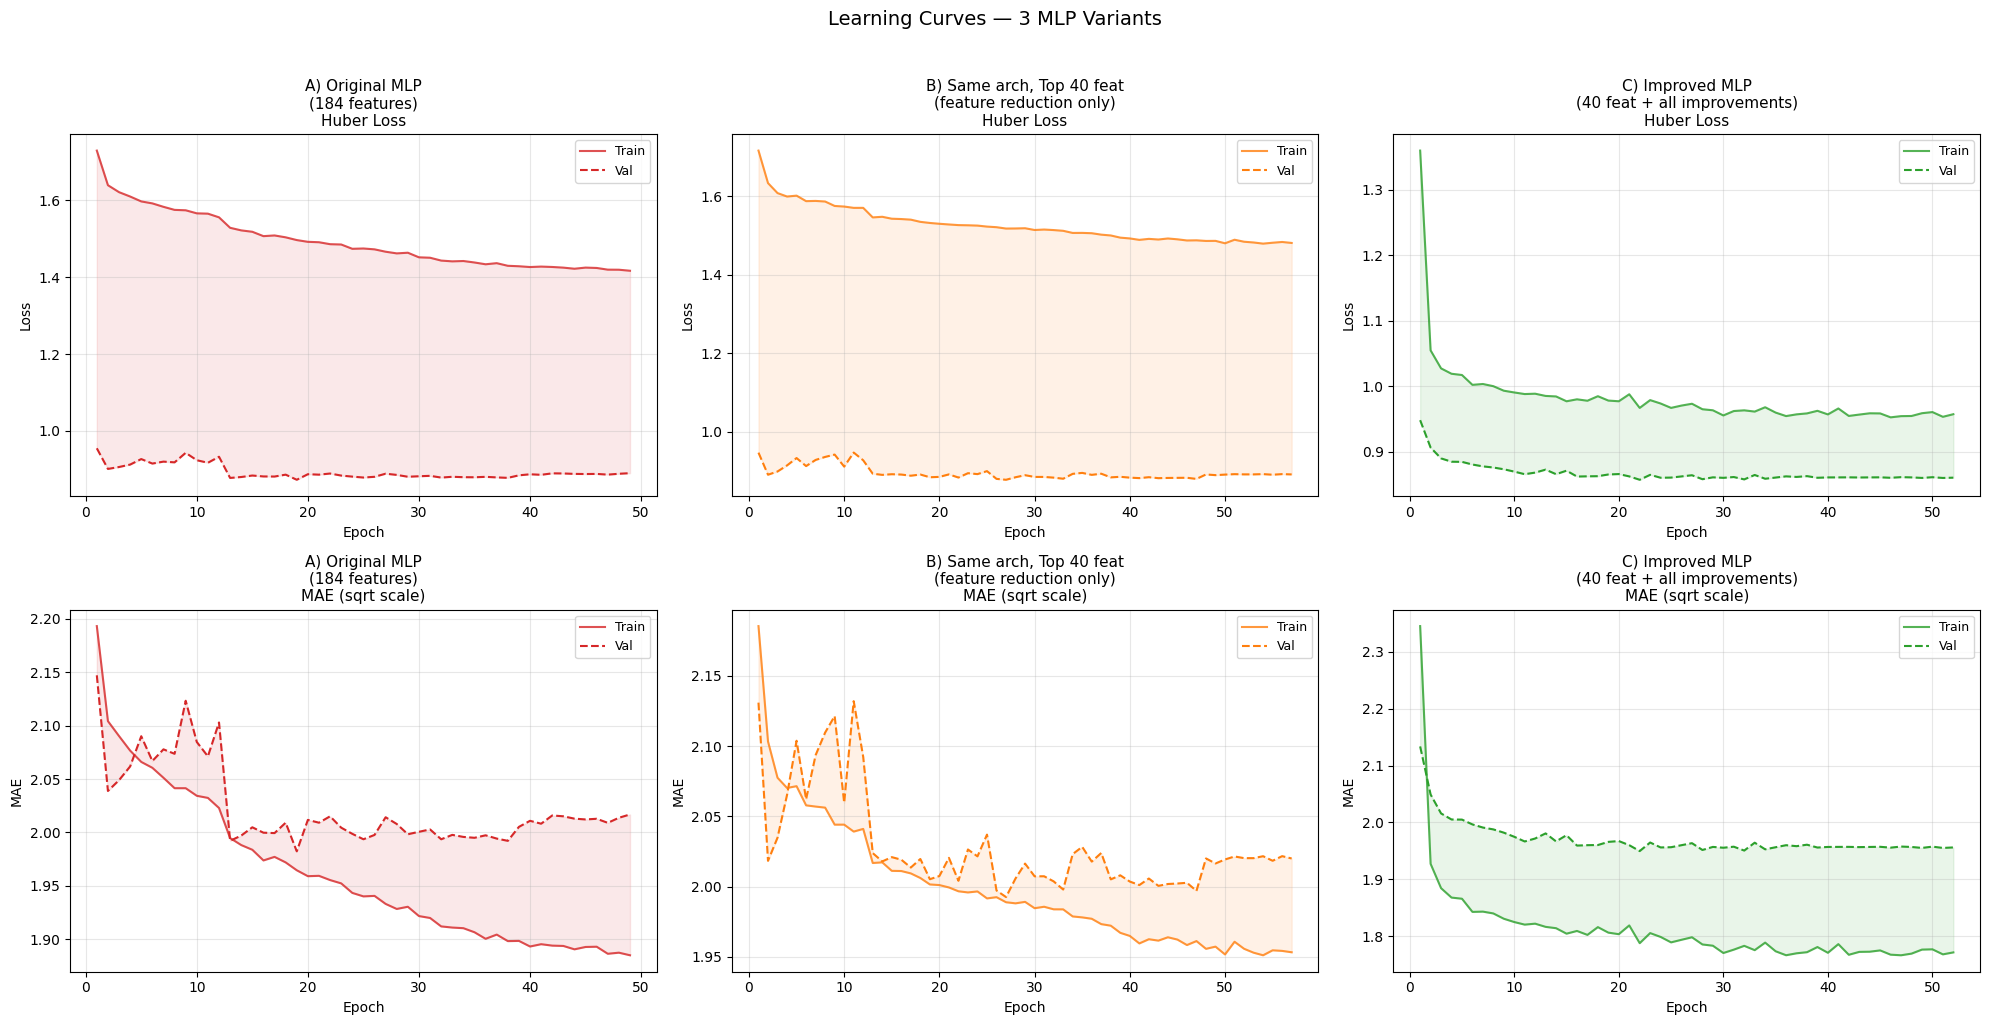

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

histories = [
    (history_a, 'A) Original MLP\n(184 features)', '#d62728'),
    (history_b, 'B) Same arch, Top 40 feat\n(feature reduction only)', '#ff7f0e'),
    (history_c, 'C) Improved MLP\n(40 feat + all improvements)', '#2ca02c'),
]

for idx, (hist, title, color) in enumerate(histories):
    epochs = range(1, len(hist.history['loss']) + 1)

    # --- Loss ---
    ax = axes[0, idx]
    ax.plot(epochs, hist.history['loss'], label='Train', color=color, alpha=0.8)
    ax.plot(epochs, hist.history['val_loss'], label='Val', color=color, linestyle='--')
    ax.fill_between(epochs, hist.history['loss'], hist.history['val_loss'],
                    alpha=0.1, color=color)
    ax.set_title(f'{title}\nHuber Loss', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # --- MAE ---
    ax = axes[1, idx]
    ax.plot(epochs, hist.history['mae'], label='Train', color=color, alpha=0.8)
    ax.plot(epochs, hist.history['val_mae'], label='Val', color=color, linestyle='--')
    ax.fill_between(epochs, hist.history['mae'], hist.history['val_mae'],
                    alpha=0.1, color=color)
    ax.set_title(f'{title}\nMAE (sqrt scale)', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MAE')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Learning Curves — 3 MLP Variants', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/mlp_comparison_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

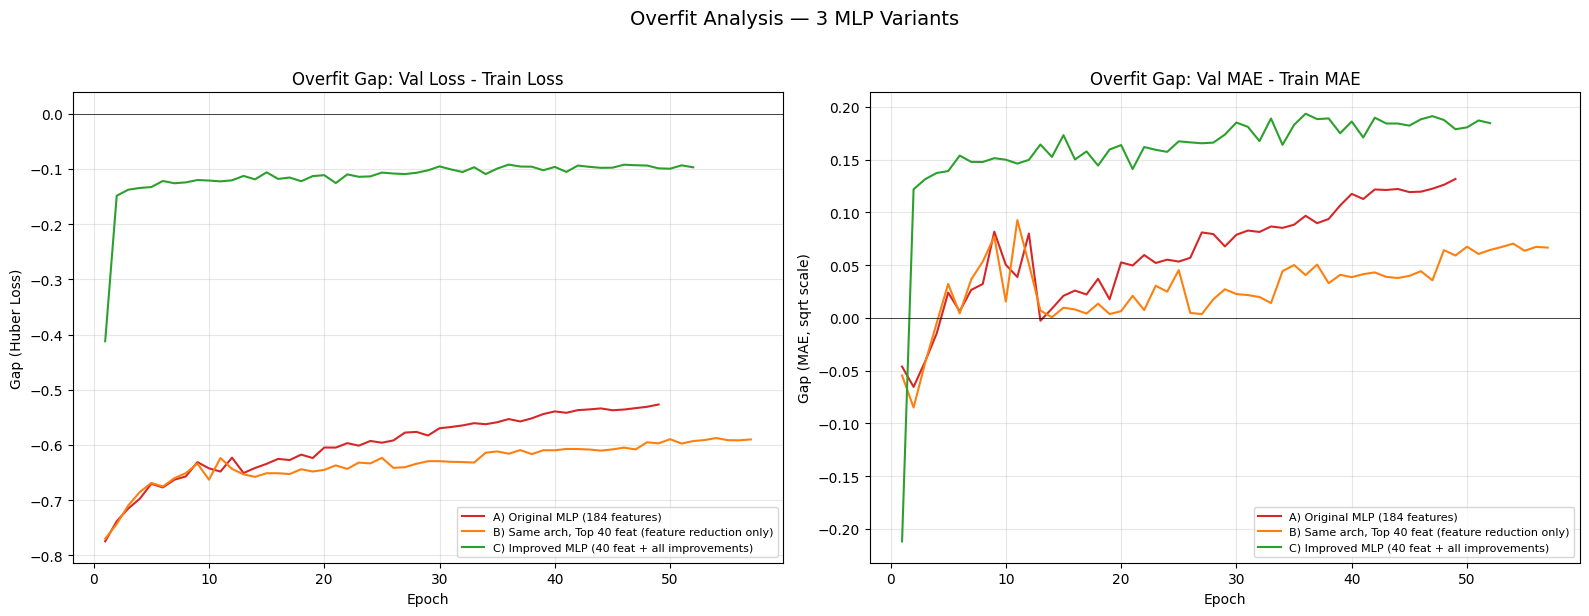

In [14]:
# --- Overlay: train-val gap comparison ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for hist, label, color in histories:
    epochs = range(1, len(hist.history['loss']) + 1)

    # Loss gap
    loss_gap = [v - t for t, v in zip(hist.history['loss'], hist.history['val_loss'])]
    axes[0].plot(epochs, loss_gap, label=label.replace('\n', ' '), color=color, linewidth=1.5)

    # MAE gap
    mae_gap = [v - t for t, v in zip(hist.history['mae'], hist.history['val_mae'])]
    axes[1].plot(epochs, mae_gap, label=label.replace('\n', ' '), color=color, linewidth=1.5)

axes[0].set_title('Overfit Gap: Val Loss - Train Loss', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Gap (Huber Loss)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

axes[1].set_title('Overfit Gap: Val MAE - Train MAE', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Gap (MAE, sqrt scale)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.suptitle('Overfit Analysis — 3 MLP Variants', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/mlp_comparison_overfit_gap.png', dpi=150, bbox_inches='tight')
plt.show()

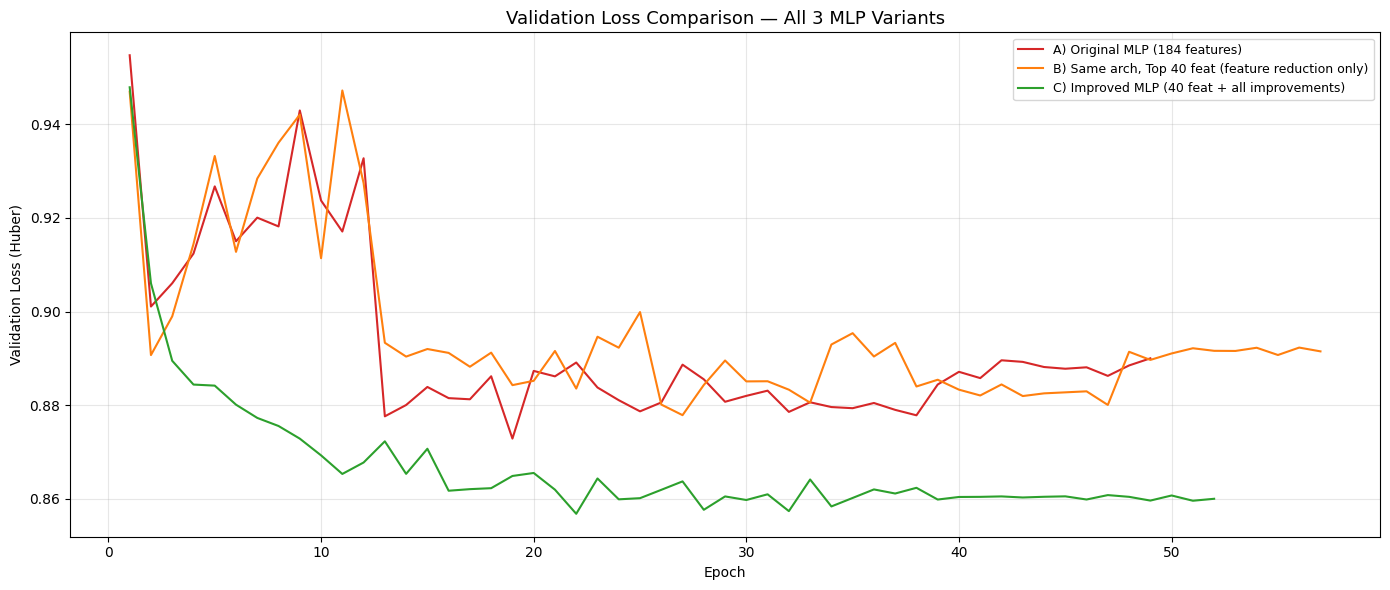

In [15]:
# --- Overlay: validation loss for all 3 models on the same plot ---
fig, ax = plt.subplots(figsize=(14, 6))

for hist, label, color in histories:
    epochs = range(1, len(hist.history['val_loss']) + 1)
    ax.plot(epochs, hist.history['val_loss'], label=label.replace('\n', ' '),
            color=color, linewidth=1.5)

ax.set_title('Validation Loss Comparison — All 3 MLP Variants', fontsize=13)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss (Huber)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/mlp_comparison_val_loss_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Final Results Table

In [16]:
# Compute final train/val metrics for overfit analysis
def get_final_metrics(hist):
    """Extract final train/val loss and MAE from history."""
    # Find the best epoch (minimum val_loss)
    best_epoch = np.argmin(hist.history['val_loss'])
    return {
        'Best Epoch': best_epoch + 1,
        'Train Loss': hist.history['loss'][best_epoch],
        'Val Loss': hist.history['val_loss'][best_epoch],
        'Loss Gap': hist.history['val_loss'][best_epoch] - hist.history['loss'][best_epoch],
        'Train MAE (sqrt)': hist.history['mae'][best_epoch],
        'Val MAE (sqrt)': hist.history['val_mae'][best_epoch],
        'MAE Gap (sqrt)': hist.history['val_mae'][best_epoch] - hist.history['mae'][best_epoch],
    }

results = {}

# Model A
r = get_final_metrics(history_a)
r.update({'Test MAE': mae_a, 'Test RMSE': rmse_a, 'Test R2': r2_a, 'Features': 184})
results['A) Original MLP (184 feat)'] = r

# Model B
r = get_final_metrics(history_b)
r.update({'Test MAE': mae_b, 'Test RMSE': rmse_b, 'Test R2': r2_b, 'Features': 40})
results['B) Same arch (40 feat)'] = r

# Model C
r = get_final_metrics(history_c)
r.update({'Test MAE': mae_c, 'Test RMSE': rmse_c, 'Test R2': r2_c, 'Features': 40})
results['C) Improved MLP (40 feat)'] = r

results_df = pd.DataFrame(results).T
results_df.index.name = 'Model'

print('\n' + '=' * 100)
print('FINAL MLP COMPARISON')
print('=' * 100)
print(results_df.round(4).to_string())
print('=' * 100)

# Key comparisons
print('\n--- Key Comparisons ---')
print(f'Feature reduction impact (A vs B):')
print(f'  Test R2:     {r2_a:.4f} -> {r2_b:.4f} ({"+" if r2_b > r2_a else ""}{r2_b - r2_a:.4f})')
print(f'  Test MAE:    {mae_a:.2f} -> {mae_b:.2f} ({"+" if mae_b > mae_a else ""}{mae_b - mae_a:.2f})')
print(f'  Overfit gap: {results["A) Original MLP (184 feat)"]["Loss Gap"]:.4f} -> {results["B) Same arch (40 feat)"]["Loss Gap"]:.4f}')
print()
print(f'All improvements impact (A vs C):')
print(f'  Test R2:     {r2_a:.4f} -> {r2_c:.4f} ({"+" if r2_c > r2_a else ""}{r2_c - r2_a:.4f})')
print(f'  Test MAE:    {mae_a:.2f} -> {mae_c:.2f} ({"+" if mae_c > mae_a else ""}{mae_c - mae_a:.2f})')
print(f'  Overfit gap: {results["A) Original MLP (184 feat)"]["Loss Gap"]:.4f} -> {results["C) Improved MLP (40 feat)"]["Loss Gap"]:.4f}')


FINAL MLP COMPARISON
                            Best Epoch  Train Loss  Val Loss  Loss Gap  Train MAE (sqrt)  Val MAE (sqrt)  MAE Gap (sqrt)  Test MAE  Test RMSE  Test R2  Features
Model                                                                                                                                                           
A) Original MLP (184 feat)        19.0      1.4965    0.8729   -0.6236            1.9646          1.9824          0.0177   18.1029    25.6247   0.3079     184.0
B) Same arch (40 feat)            27.0      1.5181    0.8779   -0.6402            1.9889          1.9925          0.0037   18.1950    25.2329   0.3289      40.0
C) Improved MLP (40 feat)         22.0      0.9667    0.8568   -0.1099            1.7875          1.9496          0.1621   17.9103    25.4919   0.3151      40.0

--- Key Comparisons ---
Feature reduction impact (A vs B):
  Test R2:     0.3079 -> 0.3289 (+0.0210)
  Test MAE:    18.10 -> 18.19 (+0.09)
  Overfit gap: -0.6236 -> -0.6402

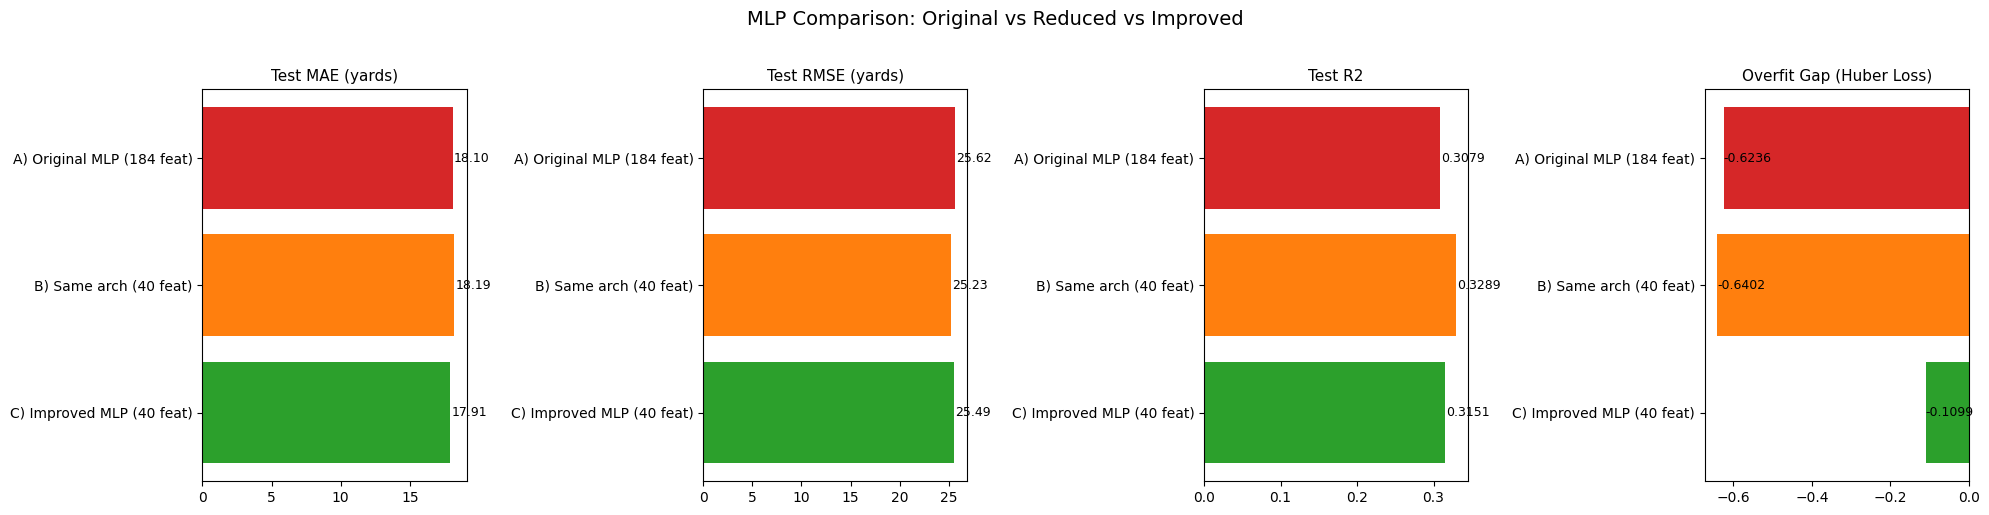

In [17]:
# --- Summary bar chart ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

model_names = list(results.keys())
colors = ['#d62728', '#ff7f0e', '#2ca02c']

for idx, (metric, title, fmt) in enumerate([
    ('Test MAE', 'Test MAE (yards)', '.2f'),
    ('Test RMSE', 'Test RMSE (yards)', '.2f'),
    ('Test R2', 'Test R2', '.4f'),
    ('Loss Gap', 'Overfit Gap (Huber Loss)', '.4f'),
]):
    ax = axes[idx]
    vals = [results[m][metric] for m in model_names]
    bars = ax.barh(model_names, vals, color=colors)
    ax.set_title(title, fontsize=11)
    ax.invert_yaxis()
    for i, v in enumerate(vals):
        ax.text(v + 0.005 * max(vals), i, f'{v:{fmt}}', va='center', fontsize=9)

plt.suptitle('MLP Comparison: Original vs Reduced vs Improved', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/mlp_comparison_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Save results
output = {
    'model_a': {
        'name': 'Original MLP (184 features)',
        'params': ORIG_PARAMS,
        'test_mae': round(mae_a, 4), 'test_rmse': round(rmse_a, 4), 'test_r2': round(r2_a, 4),
    },
    'model_b': {
        'name': 'Same architecture (40 features)',
        'params': ORIG_PARAMS,
        'test_mae': round(mae_b, 4), 'test_rmse': round(rmse_b, 4), 'test_r2': round(r2_b, 4),
    },
    'model_c': {
        'name': 'Improved MLP (40 features)',
        'params': improved_study.best_params,
        'test_mae': round(mae_c, 4), 'test_rmse': round(rmse_c, 4), 'test_r2': round(r2_c, 4),
    },
}

with open('../results/mlp_comparison_results.json', 'w') as f:
    json.dump(output, f, indent=2, default=str)

results_df.to_csv('../results/mlp_comparison_results.csv')

print('Results saved to:')
print('  results/mlp_comparison_results.json')
print('  results/mlp_comparison_results.csv')

Results saved to:
  results/mlp_comparison_results.json
  results/mlp_comparison_results.csv
